# Uncertainty Propagation for Autoregressive Models

Track how uncertainty grows during time-stepping.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.propagation import UncertaintyRollout
from deepuq.models import MLP
from deepuq.methods.mc_dropout import MCDropoutWrapper

## Train Autoregressive Model

In [2]:
# Simple 4D dynamical system: x_{t+1} = f(x_t)
# Lorenz-like system discretized
np.random.seed(42)
torch.manual_seed(42)

def dynamics(x):
    """Simple nonlinear dynamics for 4D system."""
    x1, x2, x3, x4 = x[..., 0], x[..., 1], x[..., 2], x[..., 3]
    dx1 = 0.9 * x1 - 0.1 * x2 * x3
    dx2 = 0.1 * x1 + 0.9 * x2 + 0.05 * x4
    dx3 = -0.1 * x1 + 0.95 * x3 + 0.1 * x2
    dx4 = 0.05 * x2 - 0.9 * x4
    return np.stack([dx1, dx2, dx3, dx4], axis=-1)

# Generate trajectory data
n_trajectories = 100
traj_len = 50
X_train, y_train = [], []

for _ in range(n_trajectories):
    x = np.random.randn(4) * 0.5
    for t in range(traj_len):
        x_next = dynamics(x) + np.random.randn(4) * 0.01
        X_train.append(x)
        y_train.append(x_next)
        x = x_next

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)
print(f"Training data: {X_train.shape[0]} transitions")

# Train MLP with MC Dropout
model = MLP(input_dim=4, hidden_dims=[64, 64], output_dim=4, p_drop=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(200):
    optimizer.zero_grad()
    pred = model(X_train)
    loss = torch.nn.functional.mse_loss(pred, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.6f}")

Training data: 5000 transitions


Epoch 50, Loss: 0.007150
Epoch 100, Loss: 0.003350


Epoch 150, Loss: 0.002255
Epoch 200, Loss: 0.001932


## Propagate Uncertainty

In [3]:
# Wrap model with MC Dropout for uncertainty
uq_model = MCDropoutWrapper(model, n_mc=50, apply_softmax=False)

# Create uncertainty rollout with sampling propagation
rollout = UncertaintyRollout(uq_model, propagation="sampling")

# Initial condition
x0 = torch.tensor([0.5, -0.3, 0.2, 0.1], dtype=torch.float32)

# Predict trajectory for 20 steps (returns list of UQResult)
trajectory = rollout.predict_trajectory(x0, n_steps=20)
print(f"Trajectory length: {len(trajectory)} steps")
print(f"Each step mean shape: {trajectory[0].mean.shape}")

Trajectory length: 20 steps
Each step mean shape: torch.Size([1, 4])


## Visualize Uncertainty Growth

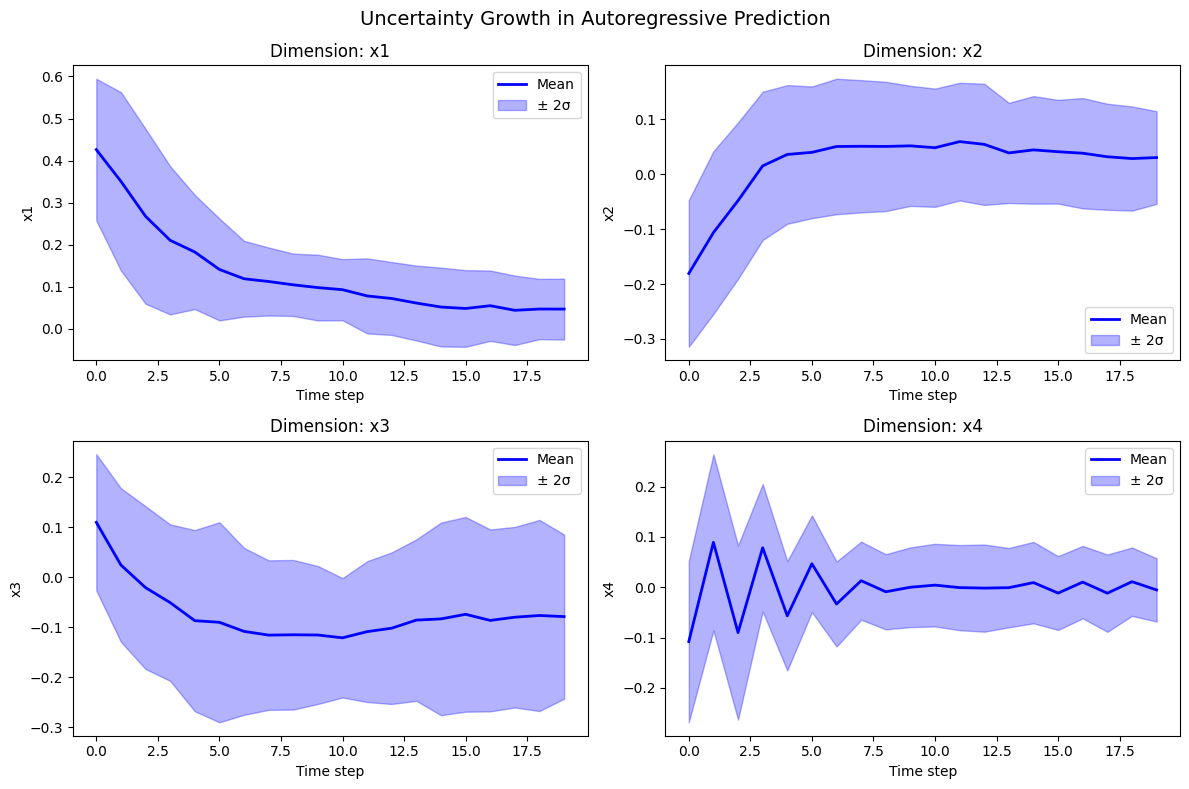

In [4]:
# Extract means and stds from trajectory (list of UQResult)
means = torch.cat([t.mean for t in trajectory], dim=0).numpy()  # (20, 4)
stds = torch.cat([t.epistemic_var.sqrt() for t in trajectory], dim=0).numpy()  # (20, 4)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
dim_names = ["x1", "x2", "x3", "x4"]
time = np.arange(means.shape[0])

for i, (ax, name) in enumerate(zip(axes.ravel(), dim_names)):
    mean_i = means[:, i]
    std_i = stds[:, i]
    
    ax.plot(time, mean_i, "b-", linewidth=2, label="Mean")
    ax.fill_between(time, mean_i - 2*std_i, mean_i + 2*std_i,
                    alpha=0.3, color="blue", label="\u00b1 2\u03c3")
    ax.set_xlabel("Time step")
    ax.set_ylabel(name)
    ax.set_title(f"Dimension: {name}")
    ax.legend()

plt.suptitle("Uncertainty Growth in Autoregressive Prediction", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Compute uncertainty growth rate (returns single float)
growth_rate = UncertaintyRollout.uncertainty_growth_rate(trajectory)
print(f"Average uncertainty growth rate: {growth_rate:.4f} per step")

Average uncertainty growth rate: 0.9743 per step
